In [1]:
! pip install gurobipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 51.4 MB/s eta 0:00:00


In [2]:
import gurobipy as gp
import pandas as pd
from gurobipy import GRB

In [3]:
production = ['Baltimore','Cleveland','Little Rock','Birmingham','Charleston']
distribution = ['Columbia','Indianapolis','Lexington','Nashville','Richmond','St. Louis']

m = gp.Model('widgets') # define a model for decision problem

Restricted license - for non-production use only - expires 2027-11-29


In [4]:
cost_df = pd.read_csv('transport_cost.csv', index_col=0)

p    = cost_df.index.tolist()
d  = cost_df.columns.tolist()

In [5]:
production

['Baltimore', 'Cleveland', 'Little Rock', 'Birmingham', 'Charleston']

In [6]:
distribution

['Columbia', 'Indianapolis', 'Lexington', 'Nashville', 'Richmond', 'St. Louis']

In [7]:
cost_df

,Columbia,Indianapolis,Lexington,Nashville,Richmond,St. Louis
Production\Distribution,,,,,,
Baltimore,35,62,45,58,20,72
Cleveland,42,30,38,52,45,48
Little Rock,60,55,70,40,85,38
Birmingham,55,65,62,35,75,52
Charleston,30,68,40,50,28,78


In [8]:
supply = {
    'Baltimore':    400,
    'Cleveland':    450,
    'Little Rock':  350,
    'Birmingham':   400,
    'Charleston':   300,
}

demand = {
    'Columbia':      250,
    'Indianapolis':  300,
    'Lexington':     200,
    'Nashville':     350,
    'Richmond':      250,
    'St. Louis':     300,
}

In [9]:
x = m.addVars(production,distribution,name='prod_ship')
m.update()

**Subject to the following constraints**:
1. Each production plant must ship at least 50% of
its available supply
2. No production plant may ship more than 100% of its available supply.
3. Each distribution center must receive at least 75% of its demand.
4. No distribution center may receive more than 100% of its demand.
5. Shipments cannot be negative.

In [10]:
# Supply Constraints (each plant ships between 50% and 100% of its supply)
for p in production:
    m.addConstr(gp.quicksum(x[p,d] for d in distribution) <= supply[p],       name=f'meet_supply_max_{p}')
    m.addConstr(gp.quicksum(x[p,d] for d in distribution) >= 0.5 * supply[p], name=f'meet_supply_min_{p}')

# Demand Constraints (each warehouse receives between 75% and 100% of its demand)
for d in distribution:
    m.addConstr(gp.quicksum(x[p,d] for p in production) <= demand[d],          name=f'meet_demand_max_{d}')
    m.addConstr(gp.quicksum(x[p,d] for p in production) >= 0.75 * demand[d],  name=f'meet_demand_min_{d}')

m.update()

In [11]:
cost_df.loc[production[0],distribution[0]]

np.int64(35)

Requirements
Determine the number of units to transport from each production plant to each distribution center.
Minimize the total transportation cost.


In [12]:
#Set Objective
m.setObjective(gp.quicksum(cost_df.loc[p,d] * x[p,d] for p in production for d in distribution), GRB.MINIMIZE)
m.update()

In [13]:
m.optimize()

Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 22 rows, 30 columns and 120 nonzeros (Min)
Model fingerprint: 0x82c43b90
Model has 30 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [2e+01, 8e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [2e+02, 4e+02]

Presolve removed 11 rows and 0 columns
Presolve time: 0.01s
Presolved: 11 rows, 41 columns, 71 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    0.0000000e+00   2.734375e+02   0.000000e+00      0s
      14    3.9625000e+04   0.000000e+00   0.000000e+00      0s

Solved in 14 iterations and 0.02 seconds (0.00 work units)
Optimal objective  3.962500000e+04


In [14]:
# Extract our solution we need:
all_vars = {v.varName : v.x for v in m.getVars()}
{k: v for k, v in all_vars.items() if v > 0}

{'prod_ship[Baltimore,Columbia]': 12.5,
 'prod_ship[Baltimore,Richmond]': 187.5,
 'prod_ship[Cleveland,Indianapolis]': 225.0,
 'prod_ship[Cleveland,Lexington]': 150.0,
 'prod_ship[Little Rock,St. Louis]': 225.0,
 'prod_ship[Birmingham,Nashville]': 262.5,
 'prod_ship[Charleston,Columbia]': 175.0}

In [15]:
# How much supply actually goes out?
shipment_solution_values = m.getAttr('X',x)
total_shipment_out = {
    p_loc: sum(shipment_solution_values.get((p_loc, d_loc), 0) for d_loc in distribution)
    for p_loc in production
}
x_val = pd.Series(total_shipment_out, name='total_shipment_out')
sol = pd.concat([cost_df,x_val],axis=1)

supply_series = pd.Series(supply)
remaining_goods = pd.DataFrame({
    'Remaining': supply_series - x_val,
    'Utilization': x_val / supply_series
})
remaining_goods

,Remaining,Utilization
Baltimore,200.0,0.500000
Cleveland,75.0,0.833333
Little Rock,125.0,0.642857
Birmingham,137.5,0.656250
Charleston,125.0,0.583333


In [16]:
m.write('widget_shipment.lp')
m.write('widget_shipment.sol')

In [17]:
# Shadow prices: how much would total cost change per unit change in each constraint's RHS
constraints_df = pd.DataFrame({
    'Constraint': [c.ConstrName for c in m.getConstrs()],
    'Shadow Price (Pi)': [c.Pi for c in m.getConstrs()],
    'Slack': [c.Slack for c in m.getConstrs()],
})
constraints_df

# Reduced costs: how much cheaper an unused route would need to be to enter the solution
reduced_cost_df = pd.DataFrame({
    'Route': [v.VarName for v in m.getVars()],
    'Value': [v.X for v in m.getVars()],
    'Reduced Cost': [v.RC for v in m.getVars()],
})
reduced_cost_df[reduced_cost_df['Value'] == 0].sort_values('Reduced Cost')

,Route,Value,Reduced Cost
2,"prod_ship[Baltimore,Lexington]",0.0,2.0
26,"prod_ship[Charleston,Lexington]",0.0,2.0
15,"prod_ship[Little Rock,Nashville]",0.0,5.0
11,"prod_ship[Cleveland,St. Louis]",0.0,10.0
6,"prod_ship[Cleveland,Columbia]",0.0,12.0
28,"prod_ship[Charleston,Richmond]",0.0,13.0
23,"prod_ship[Birmingham,St. Louis]",0.0,14.0
27,"prod_ship[Charleston,Nashville]",0.0,15.0
9,"prod_ship[Cleveland,Nashville]",0.0,17.0
3,"prod_ship[Baltimore,Nashville]",0.0,18.0


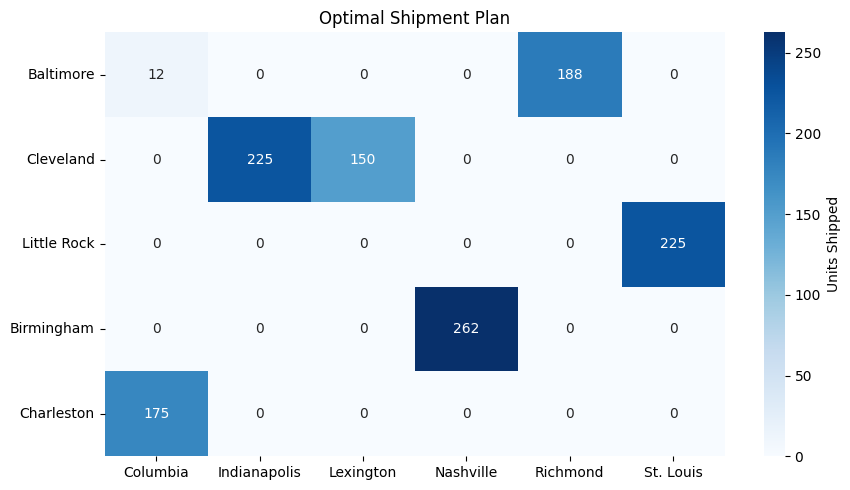

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Shipment heatmap
shipment_matrix = pd.DataFrame(
    [[x[p, d].X for d in distribution] for p in production],
    index=production, columns=distribution
)
plt.figure(figsize=(9, 5))
sns.heatmap(shipment_matrix, annot=True, fmt='.0f', cmap='Blues', cbar_kws={'label': 'Units Shipped'})
plt.title('Optimal Shipment Plan')
plt.tight_layout()
plt.show()

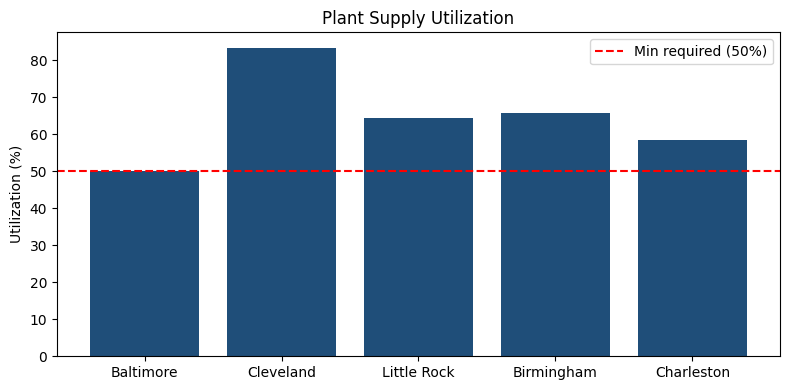

In [20]:
# Utilization bar chart
plt.figure(figsize=(8, 4))
plt.bar(remaining_goods.index, remaining_goods['Utilization'] * 100, color='#1F4E79')
plt.axhline(50, color='red', linestyle='--', label='Min required (50%)')
plt.ylabel('Utilization (%)')
plt.title('Plant Supply Utilization')
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
if m.Status == GRB.INFEASIBLE:
    m.computeIIS()
    m.write('infeasible_model.ilp')
    print("Conflicting constraints:")
    for c in m.getConstrs():
        if c.IISConstr:
            print(f"  {c.ConstrName}")

Every solution is feasible